In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import time


In [ ]:
#importing dataset
df=pd.read_csv("project_dataset.csv")

In [ ]:
#Performing Exploratory Data Analysis (EDA)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
#number of rows and columns
print("No. of rows=",df.shape[0])
print("No. of columns=",df.shape[1])

No. of rows= 4269
No. of columns= 13


In [ ]:
#names of columns
col_names=df.columns
for i in range(0,13):
  print(i+1,"->",col_names[i])

1 -> loan_id
2 -> no_of_dependents
3 -> education
4 -> self_employed
5 -> income_annum
6 -> loan_amount
7 -> loan_term
8 -> cibil_score
9 -> residential_assets_value
10 -> commercial_assets_value
11 -> luxury_assets_value
12 -> bank_asset_value
13 -> loan_status


In [ ]:
#checking if there is any null value
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


There is no null values in the dataset.

In [ ]:
#checking the datatypes of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


Categorical columns are-<br>
education<br>
self_employed<br>
loan_status

In [ ]:
#statistical analysis of dataset
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
#Data Preprocessing
#Removing loan_id column because it does not affect loan prediction
df=df.drop('loan_id',axis=1)

In [ ]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
#removing warnings shown in output
import warnings
warnings.filterwarnings('ignore')

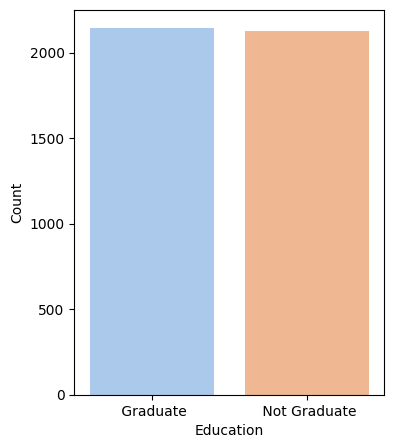

In [ ]:
#plotting graphs to see distribution of categorical features
#education
plt.figure(figsize=(4,5))
sns.countplot(x='education',data=df,palette='pastel')
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

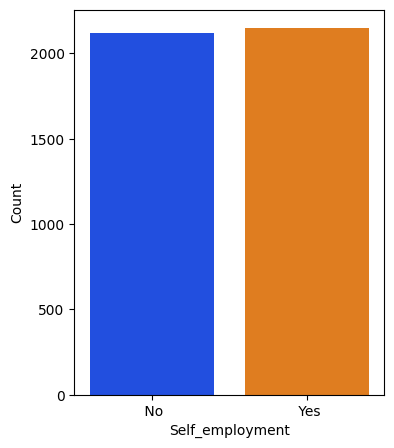

In [ ]:
#self_employed
plt.figure(figsize=(4,5))
sns.countplot(x='self_employed',data=df,palette='bright')
plt.xlabel("Self_employment")
plt.ylabel("Count")
plt.show()

There is almost similar number of both categories in education and self_employed column.

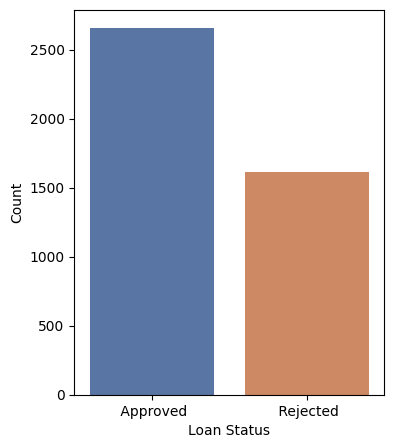

In [ ]:
#loan_status
plt.figure(figsize=(4,5))
sns.countplot(x='loan_status',data=df,palette='deep')
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

Since there is a gap between approved and rejected categories , class_weight will be used in models to avoid bias.

In [ ]:
#Label Encoding (changing categorical columns into numerical columns)
le=LabelEncoder()
df['education']=le.fit_transform(df['education'])
df['self_employed']=le.fit_transform(df['self_employed'])
df['loan_status']=le.fit_transform(df['loan_status'])
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


After Label Encoding -<br>
Education-<br>
Graduate=0<br>
Not Graduate=1<br>
Self_employment-<br>
No=0<br>
Yes=1<br>
Loan_status-<br>
Approved=0<br>
Rejected=1

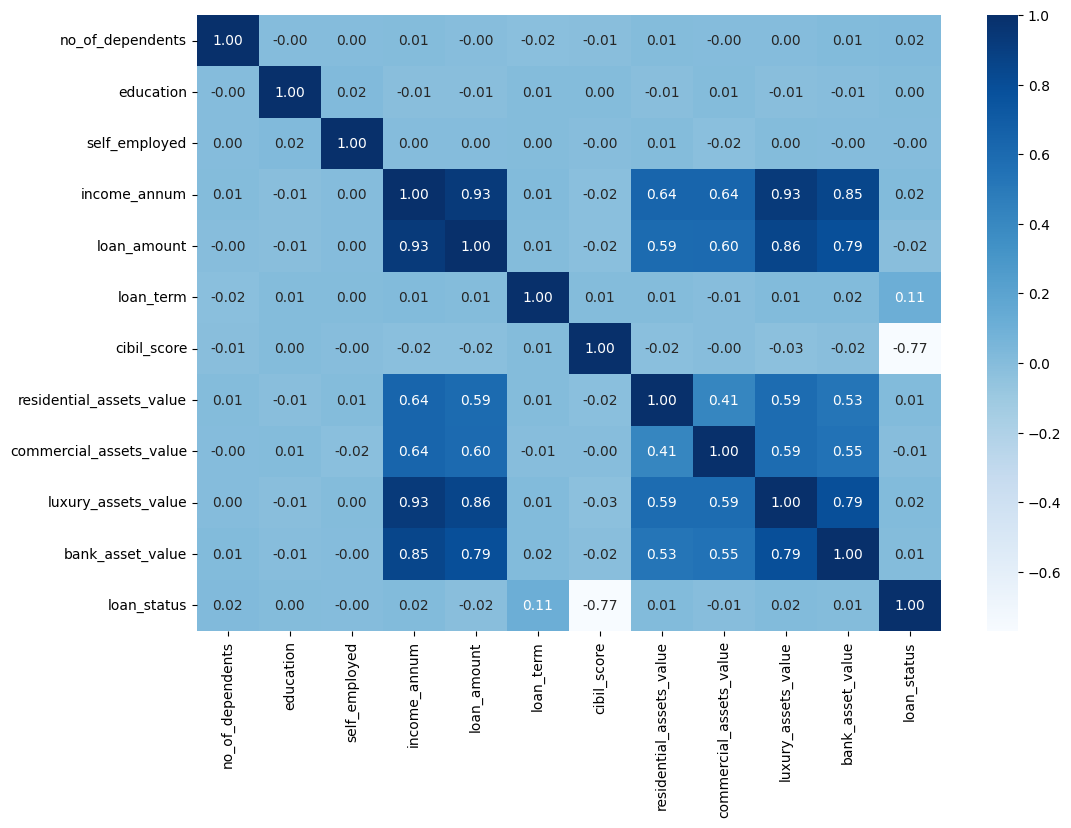

In [ ]:
#Visualizing correlation between features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='Blues')
plt.show()

Features with high positive correlation-<br>
income_annum & loan_amount<br>
income_annum & luxury_assets_value<br>
loan_amount & luxury_assets_value<br>
income_annum & bank_assets_value<br>
<br><br>
cibil_score is having high negative correlation with loan_status which is expected as loan_approval is encoded 0, so high cibil score means low chances of rejection.<br><br>
education and self_employed have zero correlation with loan_status.<br><br>
loan_term having positive correlation with loan_status shows that chances of rejection increases with increase in loan_term.<br><br>
This type of correlation matrix generally shows linear relationship between features. Features may also have another type of relationships among them.


In [ ]:
#Splitting dataset into features and target variable
X=df.drop("loan_status",axis=1)
y=df['loan_status']
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [ ]:
#Splitting dataset into training and testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.20)

In [ ]:
#Model Training
#DECISION TREE
#Training decision tree with hyperparameter tuning and cross validation accuracy
tree_params={
    "max_depth":[5,10,15,20],
    "min_samples_split":[10,20,25,30],
    "class_weight":[None,"balanced"],
    "criterion":["gini","entropy"]
}
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
dt_grid=GridSearchCV(DecisionTreeClassifier(random_state=42),cv=skf,scoring='accuracy',param_grid=tree_params)
dt_grid.fit(X_train,y_train)
print("Decision Tree:")
print("Best parameters are:",dt_grid.best_params_)
print("Best accuracy is:",dt_grid.best_score_)
best_dt=dt_grid.best_estimator_
print("Best model is:",dt_grid.best_estimator_)

Decision Tree:
Best parameters are: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 30}
Best accuracy is: 0.9838945827232797
Best model is: DecisionTreeClassifier(criterion='entropy', max_depth=15, min_samples_split=30,
                       random_state=42)


In [ ]:
#printing all 5 fold accuracy
dt_scores=cross_val_score(best_dt,X_train,y_train,cv=skf,scoring='accuracy')
print(dt_scores)
print("Mean accuracy is:",dt_scores.mean())
print("Standard deviation of accuracies is:",dt_scores.std())


[0.9897511  0.9795022  0.98682284 0.97803807 0.98535871]
Mean accuracy is: 0.9838945827232797
Standard deviation of accuracies is: 0.004440922661230765


In [ ]:
#testing data with best model
start=time.time()
pred_dt=best_dt.predict(X_test)
end=time.time()
pred_time_dt=end-start
print("Prediction metrics:")
print("Accuracy:",accuracy_score(y_test,pred_dt))
print("Precision:",precision_score(y_test,pred_dt))
print("Recall:",recall_score(y_test,pred_dt))
print("F1:",f1_score(y_test,pred_dt))
print("Prediction time:",pred_time_dt)
auc_dt=best_dt.predict_proba(X_test)[:,1]
print("AUC score is:",roc_auc_score(y_test,auc_dt))
cm_dt=confusion_matrix(y_test,pred_dt)
print("Confusion Matrix:\n",pd.DataFrame(cm_dt,index=["Actual_approved","Actual_rejected"],
                                            columns=["Predicted_approved","Predicted_rejected"]))

Prediction metrics:
Accuracy: 0.9847775175644028
Precision: 0.987220447284345
Recall: 0.9716981132075472
F1: 0.9793977812995246
Prediction time: 0.005225419998168945
AUC score is: 0.9921383647798742
Confusion Matrix:
                  Predicted_approved  Predicted_rejected
Actual_approved                 532                   4
Actual_rejected                   9                 309


In [ ]:
#training and testing accuracy
training_dt=best_dt.score(X_train,y_train)
testing_dt=best_dt.score(X_test,y_test)
print("Training accuracy is:",training_dt)
print("Testing accuracy is:",testing_dt)

Training accuracy is: 0.9906295754026354
Testing accuracy is: 0.9847775175644028


Since training and testing accuracies are almost similar and high, this is a sign of good fit model.

In [ ]:
#RANDOM FOREST
rf_params={
    "max_depth":[5,10,15,20],
    "n_estimators":[50,80,100,120,150],
    "min_samples_split":[10,20,25,30],
    "class_weight":[None,"balanced"],
    "criterion":["gini","entropy"]
}
rf_grid=GridSearchCV(RandomForestClassifier(random_state=42),cv=skf,scoring='accuracy',param_grid=rf_params)
rf_grid.fit(X_train,y_train)
print("Random Forest:")
print("Best parameters are:",rf_grid.best_params_)
print("Best accuracy is:",rf_grid.best_score_)
best_rf=rf_grid.best_estimator_
print("Best model is:",rf_grid.best_estimator_)

Random Forest:
Best parameters are: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 120}
Best accuracy is: 0.9792093704245973
Best model is: RandomForestClassifier(criterion='entropy', max_depth=15, min_samples_split=10,
                       n_estimators=120, random_state=42)


In [ ]:
#printing all 5 fold accuracy
rf_scores=cross_val_score(best_rf,X_train,y_train,cv=skf,scoring='accuracy')
print(rf_scores)
print("Mean accuracy is:",rf_scores.mean())
print("Standard deviation of accuracies is:",rf_scores.std())

[0.98535871 0.96925329 0.98828697 0.97218155 0.98096633]
Mean accuracy is: 0.9792093704245973
Standard deviation of accuracies is: 0.0073731644579878115


In [ ]:
#testing data with best model
start=time.time()
pred_rf=best_rf.predict(X_test)
end=time.time()
pred_time_rf=end-start
print("Prediction metrics:")
print("Accuracy:",accuracy_score(y_test,pred_rf))
print("Precision:",precision_score(y_test,pred_rf))
print("Recall:",recall_score(y_test,pred_rf))
print("F1:",f1_score(y_test,pred_rf))
print("Prediction time:",pred_time_rf)
auc_rf=best_rf.predict_proba(X_test)[:,1]
print("AUC score is:",roc_auc_score(y_test,auc_rf))
cm_rf=confusion_matrix(y_test,pred_rf)
print("Confusion Matrix:\n",pd.DataFrame(cm_rf,index=["Actual_approved","Actual_rejected"],
                                            columns=["Predicted_approved","Predicted_rejected"]))

Prediction metrics:
Accuracy: 0.9742388758782201
Precision: 0.9743589743589743
Recall: 0.9559748427672956
F1: 0.9650793650793651
Prediction time: 0.020125627517700195
AUC score is: 0.9981812634938515
Confusion Matrix:
                  Predicted_approved  Predicted_rejected
Actual_approved                 528                   8
Actual_rejected                  14                 304


In [ ]:
#training and testing accuracy
training_rf=best_rf.score(X_train,y_train)
testing_rf=best_rf.score(X_test,y_test)
print("Training accuracy is:",training_rf)
print("Testing accuracy is:",testing_rf)

Training accuracy is: 0.9961932650073206
Testing accuracy is: 0.9742388758782201


High value and less difference between training and testing accuracies shows that model is a good fit.

In [ ]:
#Feature scaling for algorithms- KNN, SVM & LogisticRegression
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [ ]:
#LOGISTIC REGRESSION
lr_params={
    "C":[0.01,0.1,1,5,10],
    "penalty":['l1','12','elasticnet',None],
    "solver":["lbfgs","liblinear","saga"],
    "max_iter":[100,500,1000],
    "class_weight":[None,'balanced']
}
lr_grid=GridSearchCV(LogisticRegression(random_state=42),cv=skf,scoring='accuracy',param_grid=lr_params)
lr_grid.fit(X_train_scaled,y_train)
print("Logistic Regression:")
print("Best parameters are:",lr_grid.best_params_)
print("Best accuracy is:",lr_grid.best_score_)
best_lr=lr_grid.best_estimator_
print("Best model is:",lr_grid.best_estimator_)


Logistic Regression:
Best parameters are: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Best accuracy is: 0.9428989751098097
Best model is: LogisticRegression(C=0.01, class_weight='balanced', penalty='l1',
                   random_state=42, solver='saga')


In [ ]:
#printing all 5 fold accuracy
lr_scores=cross_val_score(best_lr,X_train_scaled,y_train,cv=skf,scoring='accuracy')
print(lr_scores)
print("Mean accuracy is:",lr_scores.mean())
print("Standard deviation of accuracies is:",lr_scores.std())

[0.9443631  0.91654466 0.96486091 0.9341142  0.95461201]
Mean accuracy is: 0.9428989751098097
Standard deviation of accuracies is: 0.016693637263530587


In [ ]:
#testing data with best model
start=time.time()
pred_lr=best_lr.predict(X_test_scaled)
end=time.time()
pred_time_lr=end-start
print("Prediction metrics:")
print("Accuracy:",accuracy_score(y_test,pred_lr))
print("Precision:",precision_score(y_test,pred_lr))
print("Recall:",recall_score(y_test,pred_lr))
print("F1:",f1_score(y_test,pred_lr))
print("Prediction time:",pred_time_lr)
auc_lr=best_lr.predict_proba(X_test_scaled)[:,1]
print("AUC score is:",roc_auc_score(y_test,auc_lr))
cm_lr=confusion_matrix(y_test,pred_lr)
print("Confusion Matrix:\n",pd.DataFrame(cm_lr,index=["Actual_approved","Actual_rejected"],
                                            columns=["Predicted_approved","Predicted_rejected"]))

Prediction metrics:
Accuracy: 0.936768149882904
Precision: 0.8646408839779005
Recall: 0.9842767295597484
F1: 0.9205882352941176
Prediction time: 0.0008075237274169922
AUC score is: 0.9654469398291561
Confusion Matrix:
                  Predicted_approved  Predicted_rejected
Actual_approved                 487                  49
Actual_rejected                   5                 313


In [ ]:
#training and testing accuracy
training_lr=best_lr.score(X_train_scaled,y_train)
testing_lr=best_lr.score(X_test_scaled,y_test)
print("Training accuracy is:",training_lr)
print("Testing accuracy is:",testing_lr)

Training accuracy is: 0.9402635431918008
Testing accuracy is: 0.936768149882904


Less difference between training and testing accuracy tells that this is a good fit model.

In [ ]:
#KNN
knn_params={
    "n_neighbors":[3,5,8,10,12,20,25],
    "metric":["manhattan","euclidean"]
}
knn_grid=GridSearchCV(KNeighborsClassifier(weights="uniform"),cv=skf,scoring='accuracy',param_grid=knn_params)
knn_grid.fit(X_train_scaled,y_train)
print("KNN:")
print("Best parameters are:",knn_grid.best_params_)
print("Best accuracy is:",knn_grid.best_score_)
best_knn=knn_grid.best_estimator_
print("Best model is:",knn_grid.best_estimator_)

KNN:
Best parameters are: {'metric': 'manhattan', 'n_neighbors': 25}
Best accuracy is: 0.9177159590043923
Best model is: KNeighborsClassifier(metric='manhattan', n_neighbors=25)


In [ ]:
#printing all 5 fold accuracy
knn_scores=cross_val_score(best_knn,X_train_scaled,y_train,cv=skf,scoring='accuracy')
print(knn_scores)
print("Mean accuracy is:",knn_scores.mean())
print("Standard deviation of accuracies is:",knn_scores.std())

[0.91215227 0.90922401 0.92972182 0.90922401 0.92825769]
Mean accuracy is: 0.9177159590043923
Standard deviation of accuracies is: 0.009278465310544548


In [ ]:
#testing data with best model
start=time.time()
pred_knn=best_knn.predict(X_test_scaled)
end=time.time()
pred_time_knn=end-start
print("Prediction metrics:")
print("Accuracy:",accuracy_score(y_test,pred_knn))
print("Precision:",precision_score(y_test,pred_knn))
print("Recall:",recall_score(y_test,pred_knn))
print("F1:",f1_score(y_test,pred_knn))
print("Prediction time:",pred_time_knn)
auc_knn=best_knn.predict_proba(X_test_scaled)[:,1]
print("AUC score is:",roc_auc_score(y_test,auc_knn))
cm_knn=confusion_matrix(y_test,pred_knn)
print("Confusion Matrix:\n",pd.DataFrame(cm_knn,index=["Actual_approved","Actual_rejected"],
                                            columns=["Predicted_approved","Predicted_rejected"]))

Prediction metrics:
Accuracy: 0.9074941451990632
Precision: 0.8817891373801917
Recall: 0.8679245283018868
F1: 0.8748019017432647
Prediction time: 0.6676943302154541
AUC score is: 0.9722320003754812
Confusion Matrix:
                  Predicted_approved  Predicted_rejected
Actual_approved                 499                  37
Actual_rejected                  42                 276


In [ ]:
#training and testing accuracy
training_knn=best_knn.score(X_train_scaled,y_train)
testing_knn=best_knn.score(X_test_scaled,y_test)
print("Training accuracy is:",training_knn)
print("Testing accuracy is:",testing_knn)

Training accuracy is: 0.9358711566617862
Testing accuracy is: 0.9074941451990632


In [ ]:
#KNN_distance
knn_params={
    "n_neighbors":[3,5,8,10,12,20,25],
    "metric":["manhattan","euclidean"]
}
knn_grid_dist=GridSearchCV(KNeighborsClassifier(weights="distance"),cv=skf,scoring='accuracy',param_grid=knn_params)
knn_grid_dist.fit(X_train_scaled,y_train)
print("KNN:")
print("Best parameters are:",knn_grid_dist.best_params_)
print("Best accuracy is:",knn_grid_dist.best_score_)
best_knn_dist=knn_grid_dist.best_estimator_
print("Best model is:",knn_grid_dist.best_estimator_)

KNN:
Best parameters are: {'metric': 'manhattan', 'n_neighbors': 20}
Best accuracy is: 0.9232796486090777
Best model is: KNeighborsClassifier(metric='manhattan', n_neighbors=20, weights='distance')


In [ ]:
#testing data with best model
start=time.time()
pred_knn_dist=best_knn_dist.predict(X_test_scaled)
end=time.time()
pred_time_knn_dist=end-start
print("Prediction metrics:")
print("Accuracy:",accuracy_score(y_test,pred_knn_dist))
print("Precision:",precision_score(y_test,pred_knn_dist))
print("Recall:",recall_score(y_test,pred_knn_dist))
print("F1:",f1_score(y_test,pred_knn_dist))
print("Prediction time:",pred_time_knn_dist)
auc_knn_dist=best_knn_dist.predict_proba(X_test_scaled)[:,1]
print("AUC score is:",roc_auc_score(y_test,auc_knn_dist))
cm_knn_dist=confusion_matrix(y_test,pred_knn_dist)
print("Confusion Matrix:\n",pd.DataFrame(cm_knn_dist,index=["Actual_approved","Actual_rejected"],
                                            columns=["Predicted_approved","Predicted_rejected"]))

Prediction metrics:
Accuracy: 0.9156908665105387
Precision: 0.8819875776397516
Recall: 0.8930817610062893
F1: 0.8875
Prediction time: 0.07364916801452637
AUC score is: 0.9747195625645358
Confusion Matrix:
                  Predicted_approved  Predicted_rejected
Actual_approved                 498                  38
Actual_rejected                  34                 284


In [ ]:
#training and testing accuracy
training_knn_dist=best_knn_dist.score(X_train_scaled,y_train)
testing_knn_dist=best_knn_dist.score(X_test_scaled,y_test)
print("Training accuracy is:",training_knn_dist)
print("Testing accuracy is:",testing_knn_dist)

Training accuracy is: 1.0
Testing accuracy is: 0.9156908665105387


With weights='uniform', the model showed good generalization but with weights='distance',there is overfitting in the model.Since the difference between the testing accuracies of both models is less, model with good generalization(weights='uniform')is chosen.

In [ ]:
#SVM
svm_params={
    "C":[0.01,0.1,1,10,100],
    "class_weight":[None,'balanced'],
    "kernel":['linear','rbf'],
    "gamma":['auto','scale']
}
svm_grid=GridSearchCV(SVC(random_state=42,probability=True),cv=skf,scoring='accuracy',param_grid=svm_params)
svm_grid.fit(X_train_scaled,y_train)
print("SVM:")
print("Best parameters are:",svm_grid.best_params_)
print("Best accuracy is:",svm_grid.best_score_)
best_svm=svm_grid.best_estimator_
print("Best model is:",svm_grid.best_estimator_)

SVM:
Best parameters are: {'C': 10, 'class_weight': None, 'gamma': 'auto', 'kernel': 'rbf'}
Best accuracy is: 0.9449487554904833
Best model is: SVC(C=10, gamma='auto', probability=True, random_state=42)


In [ ]:
#printing all 5 fold accuracy
svm_scores=cross_val_score(best_svm,X_train_scaled,y_train,cv=skf,scoring='accuracy')
print(svm_scores)
print("Mean accuracy is:",svm_scores.mean())
print("Standard deviation of accuracies is:",svm_scores.std())

[0.9443631  0.93557833 0.95168375 0.92825769 0.96486091]
Mean accuracy is: 0.9449487554904833
Standard deviation of accuracies is: 0.01271686720387026


In [ ]:
#testing data with best model
start=time.time()
pred_svm=best_svm.predict(X_test_scaled)
end=time.time()
pred_time_svm=end-start
print("Prediction metrics:")
print("Accuracy:",accuracy_score(y_test,pred_svm))
print("Precision:",precision_score(y_test,pred_svm))
print("Recall:",recall_score(y_test,pred_svm))
print("F1:",f1_score(y_test,pred_svm))
print("Prediction time:",pred_time_svm)
auc_svm=best_svm.predict_proba(X_test_scaled)[:,1]
print("AUC score is:",roc_auc_score(y_test,auc_svm))
cm_svm=confusion_matrix(y_test,pred_svm)
print("Confusion Matrix:\n",pd.DataFrame(cm_svm,index=["Actual_approved","Actual_rejected"],
                                            columns=["Predicted_approved","Predicted_rejected"]))

Prediction metrics:
Accuracy: 0.9402810304449649
Precision: 0.9158878504672897
Recall: 0.9245283018867925
F1: 0.92018779342723
Prediction time: 0.0769650936126709
AUC score is: 0.9869784333051723
Confusion Matrix:
                  Predicted_approved  Predicted_rejected
Actual_approved                 509                  27
Actual_rejected                  24                 294


In [ ]:
#training and testing accuracy
training_svm=best_svm.score(X_train_scaled,y_train)
testing_svm=best_svm.score(X_test_scaled,y_test)
print("Training accuracy is:",training_svm)
print("Testing accuracy is:",testing_svm)

Training accuracy is: 0.9786237188872621
Testing accuracy is: 0.9402810304449649


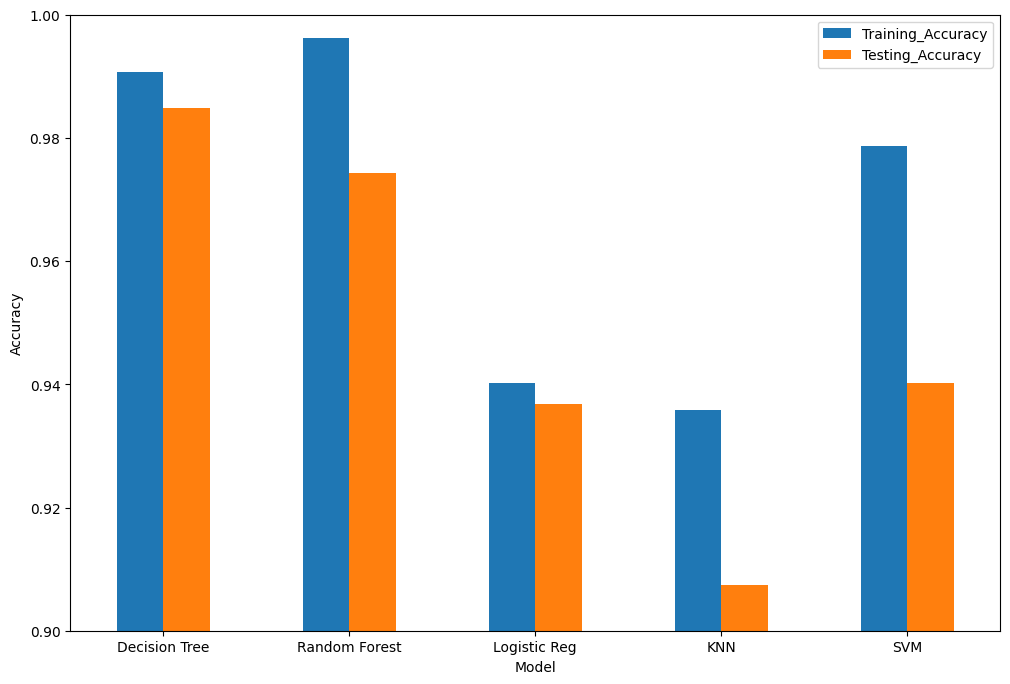

In [ ]:
#Comparing different models using graphs
#Comparing testing accuracy of each model
test_acc=pd.DataFrame({
    "Model":['Decision Tree','Random Forest','Logistic Reg','KNN','SVM'],
    "Training_Accuracy":[training_dt,training_rf,training_lr,training_knn,training_svm],
    "Testing_Accuracy":[testing_dt,testing_rf,testing_lr,testing_knn,testing_svm]
                           })
test_acc.set_index("Model").plot(kind="bar",figsize=(12,8))
plt.xticks(rotation=0)
plt.ylabel("Accuracy")
plt.ylim(0.9,1.0)
plt.show()

It can be seen that random forest got highest training accuracy while decision tree got highest testing accuracy.<br>
Difference between training and testing accuracies is least for logistic regression making it the best fit model among all.<br>High training and testing accuracies along with less difference between them makes decision tree better model.


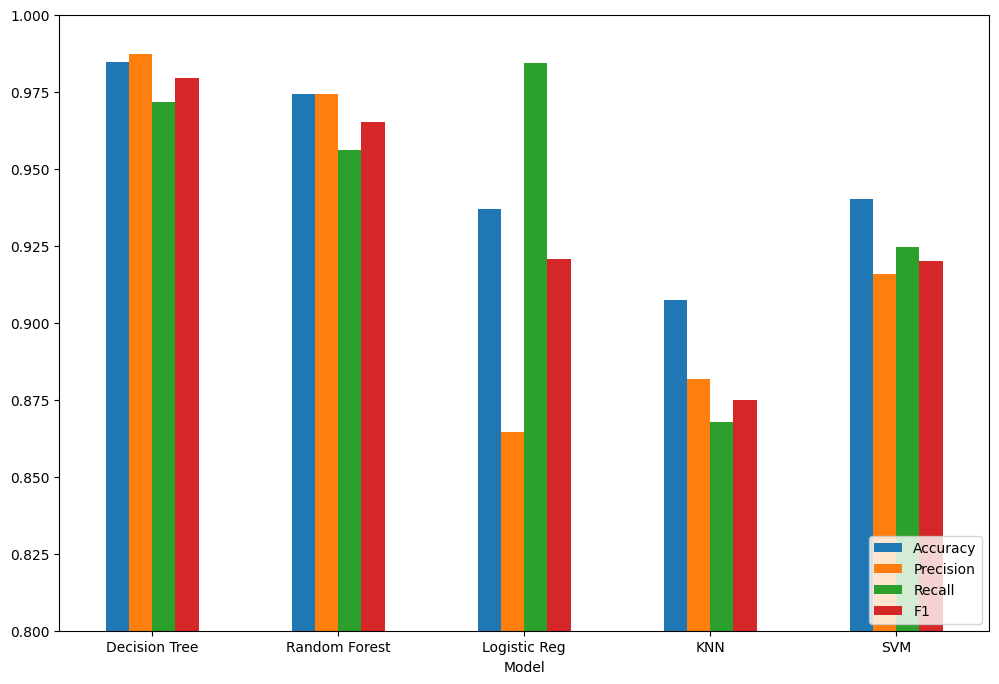

In [ ]:
#Comparing Prediction metrics
metrics=pd.DataFrame({
    "Model":['Decision Tree','Random Forest','Logistic Reg','KNN','SVM'],
    "Accuracy":[accuracy_score(y_test,pred_dt),accuracy_score(y_test,pred_rf),accuracy_score(y_test,pred_lr),
                accuracy_score(y_test,pred_knn),accuracy_score(y_test,pred_svm)],
    "Precision":[precision_score(y_test,pred_dt),precision_score(y_test,pred_rf),precision_score(y_test,pred_lr),
                 precision_score(y_test,pred_knn),precision_score(y_test,pred_svm)],
    "Recall":[recall_score(y_test,pred_dt),recall_score(y_test,pred_rf),recall_score(y_test,pred_lr),
              recall_score(y_test,pred_knn),recall_score(y_test,pred_svm)],
    "F1":[f1_score(y_test,pred_dt),f1_score(y_test,pred_rf),f1_score(y_test,pred_lr),
          f1_score(y_test,pred_knn),f1_score(y_test,pred_svm)],
    #"AUC_score":[roc_auc_score(y_test,auc_dt),roc_auc_score(y_test,auc_rf),roc_auc_score(y_test,auc_lr),
                 #roc_auc_score(y_test,auc_knn),roc_auc_score(y_test,auc_svm)]
})
metrics.set_index("Model").plot(kind='bar',figsize=(12,8))
plt.xticks(rotation=0)
plt.ylim(0.8,1.0)
plt.legend(loc='lower right')
plt.show()

Highest:<br>
Accuracy- Decision tree<br>
Precision- Decision tree<br>
Recall- Logistic Regression<br>
F1- Decision tree<br>

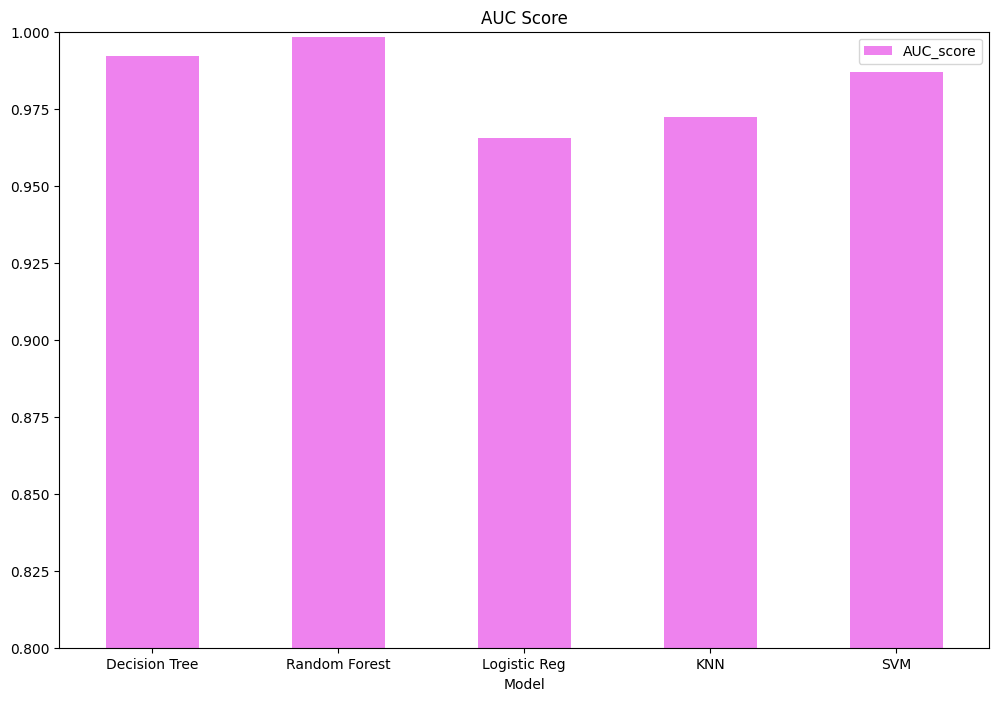

In [ ]:
#Comparing auc score
auc=pd.DataFrame({
    "Model":['Decision Tree','Random Forest','Logistic Reg','KNN','SVM'],
    "AUC_score":[roc_auc_score(y_test,auc_dt),roc_auc_score(y_test,auc_rf),roc_auc_score(y_test,auc_lr),
                 roc_auc_score(y_test,auc_knn),roc_auc_score(y_test,auc_svm)]
})
auc.set_index("Model").plot(kind='bar',figsize=(12,8),color='violet')
plt.xticks(rotation=0)
plt.ylim(0.8,1.0)
plt.title("AUC Score")
plt.show()

Random forest got highest auc score showing that it can distinguish between two classes(approved and rejected) better.<br>
Decision tree got the second highest auc score making it a better model as it also got highest accuracy, precision, recall and F1 score.

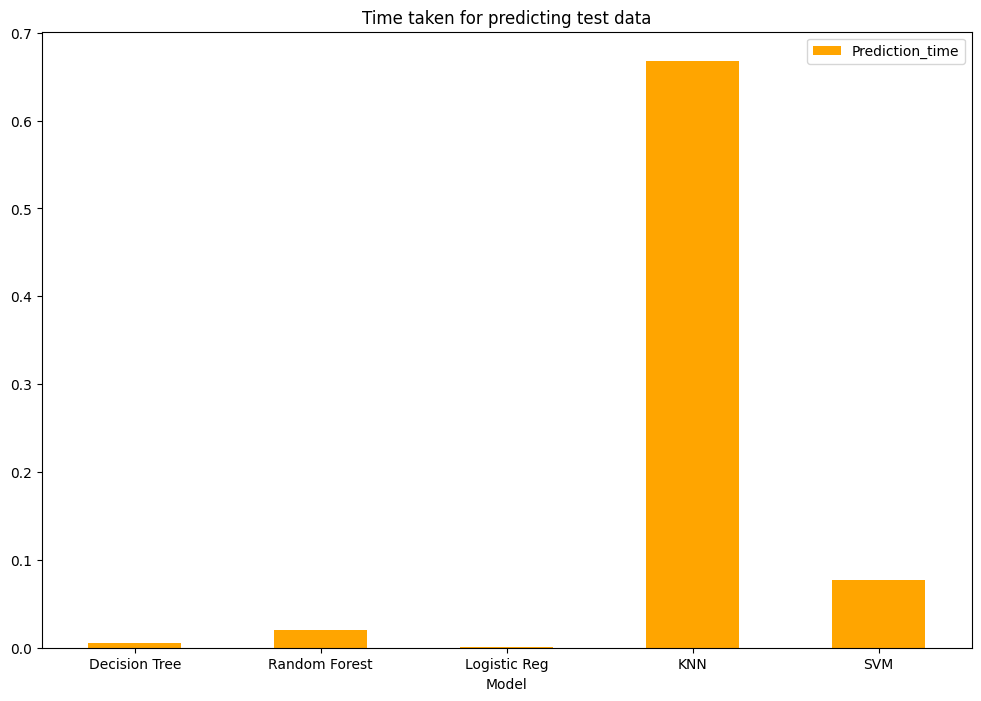

In [ ]:
#Comparing prediction time
pred_time=pd.DataFrame({
    "Model":['Decision Tree','Random Forest','Logistic Reg','KNN','SVM'],
    "Prediction_time":[pred_time_dt,pred_time_rf,pred_time_lr,pred_time_knn,pred_time_svm]
})
pred_time.set_index("Model").plot(kind='bar',figsize=(12,8),color='orange')
plt.xticks(rotation=0)
plt.title("Time taken for predicting test data")
plt.show()

Logistic regression took least time for predicting test data.

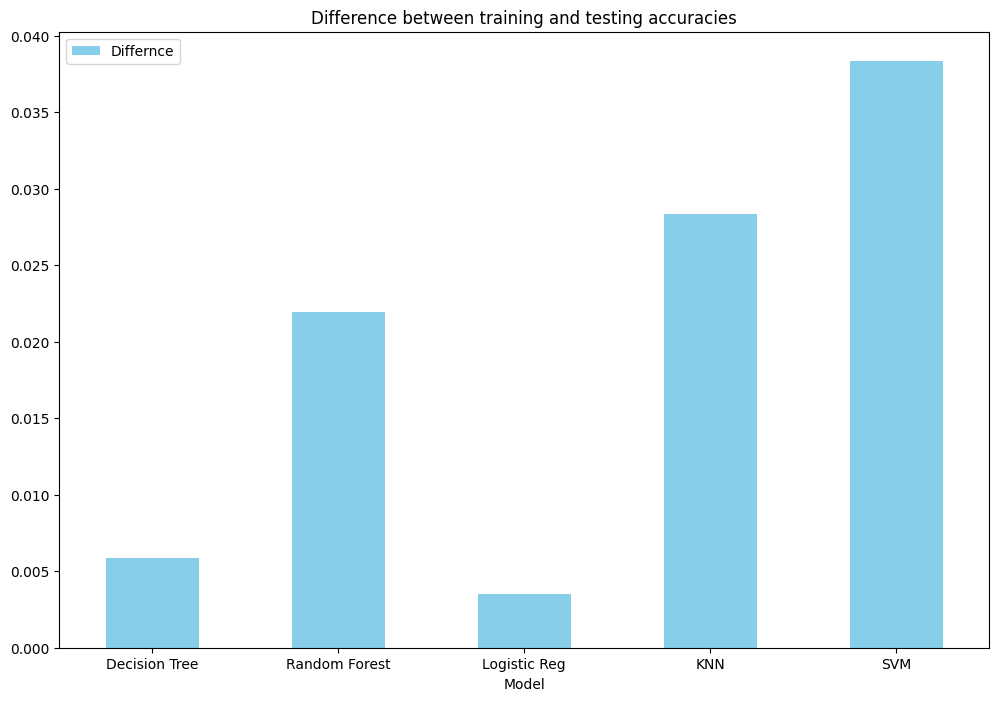

In [ ]:
#Comparing Train-Test accuracy difference
train_test_diff=pd.DataFrame({
    "Model":['Decision Tree','Random Forest','Logistic Reg','KNN','SVM'],
    "Differnce":[training_dt-testing_dt,training_rf-testing_rf,training_lr-testing_lr,
                 training_knn-testing_knn,training_svm-testing_svm]
})
train_test_diff.set_index("Model").plot(kind='bar',figsize=(12,8),color='skyblue')
plt.xticks(rotation=0)
plt.title("Difference between training and testing accuracies")
plt.show()


Logistic regression has the least difference between training and testing accuracies.Hence, it is a good fit model.

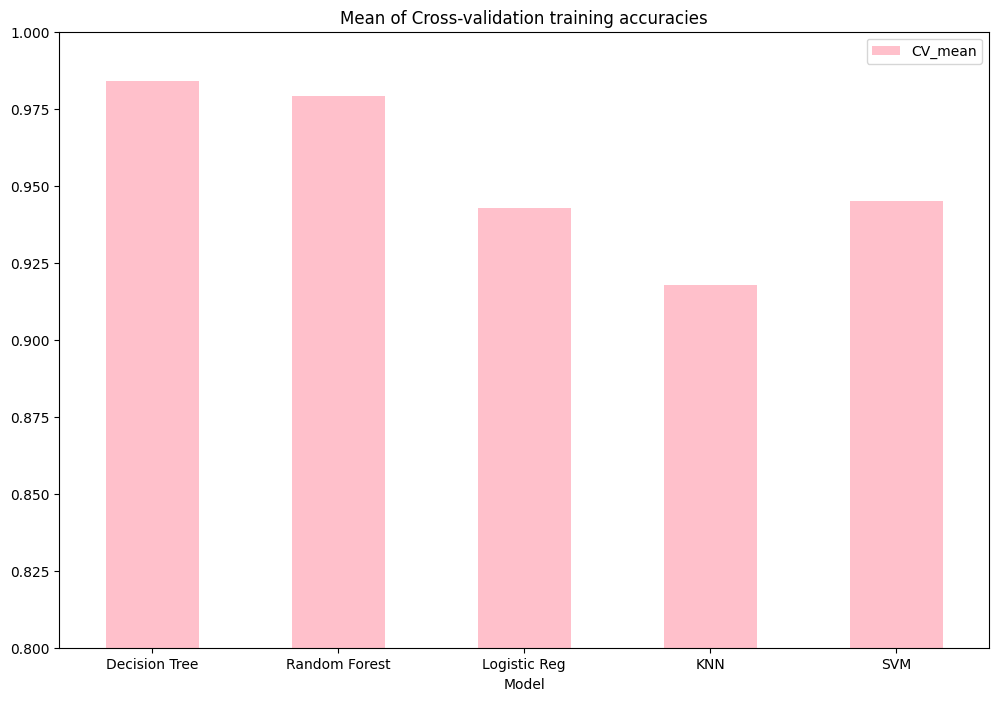

In [ ]:
#Comparing cross-validation mean training accuracy
cv1=pd.DataFrame({
    "Model":['Decision Tree','Random Forest','Logistic Reg','KNN','SVM'],
    "CV_mean":[dt_scores.mean(),rf_scores.mean(),lr_scores.mean(),knn_scores.mean(),svm_scores.mean()]
})
cv1.set_index("Model").plot(kind='bar',figsize=(12,8),color='pink')
plt.xticks(rotation=0)
plt.ylim(0.8,1.0)
plt.title("Mean of Cross-validation training accuracies")
plt.show()


Decision tree got the highest training accuracy signifying that it understood the data better.

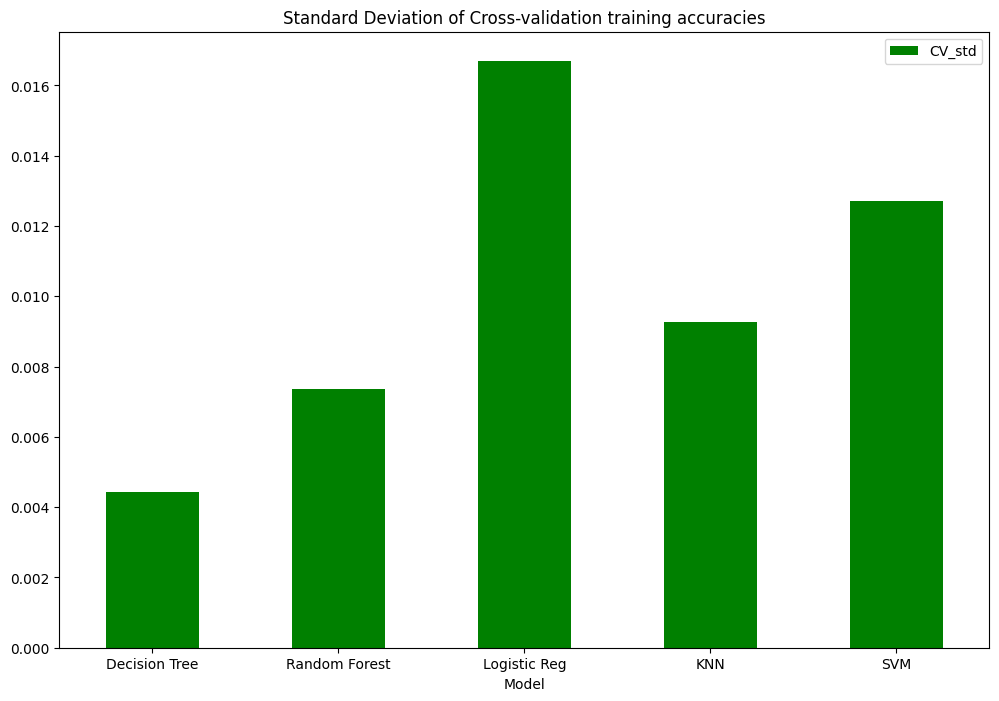

In [ ]:
#Comparing standard deviation of cross-validation training accuracies
cv2=pd.DataFrame({
    "Model":['Decision Tree','Random Forest','Logistic Reg','KNN','SVM'],
    "CV_std":[dt_scores.std(),rf_scores.std(),lr_scores.std(),knn_scores.std(),svm_scores.std()]
})
cv2.set_index("Model").plot(kind='bar',figsize=(12,8),color='green')
plt.xticks(rotation=0)
plt.title("Standard Deviation of Cross-validation training accuracies")
plt.show()

Decision tree got the least standard deviation for cross-validation training accuracies signifying that all 5 fold accuracies are not deviating much from mean making this model more stable.

Since Decision tree comes up to be the best model among all 5 models, loan approval predictions can be done using decision tree model found out by the method of GridSearch and hyperparameter tuning.